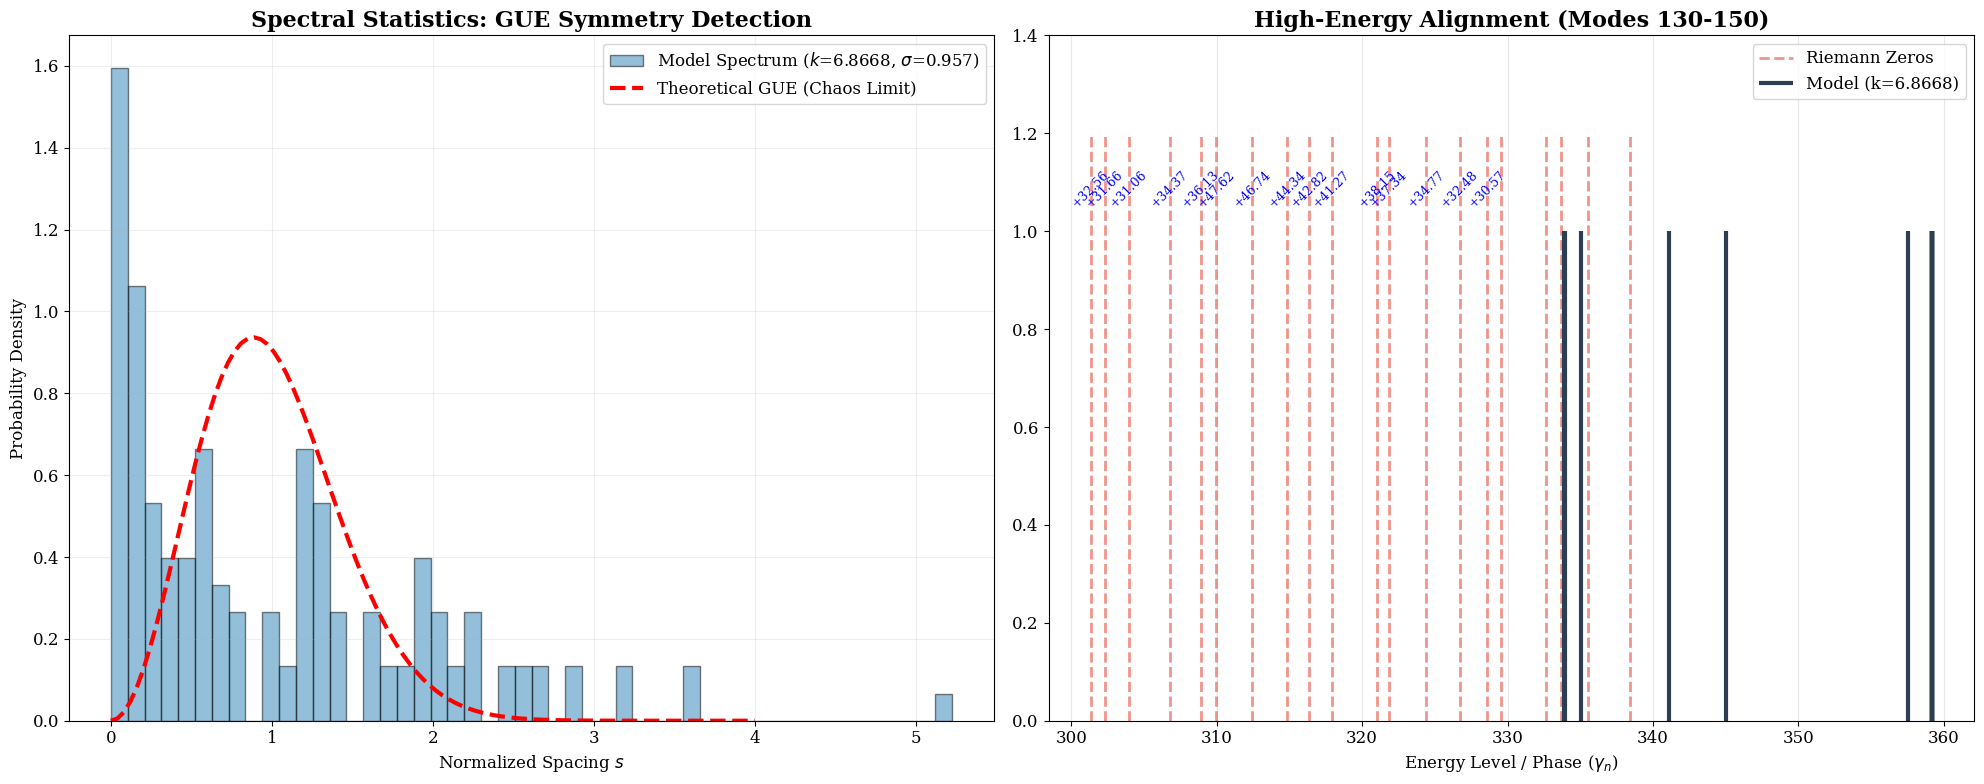

>>> 160点科研成果图已生成：Riemann_160_Mode_Brute_Force.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 权威数据集：前 160 个黎曼零点虚部 ---
TRUE_GAMMAS_160 = np.array([
    14.1347, 21.0220, 25.0108, 30.4248, 32.9350, 37.5861, 40.9187, 43.3270, 48.0051, 49.7738,
    52.9703, 56.4462, 59.3470, 60.8317, 65.1125, 67.0798, 69.5464, 72.0671, 75.7046, 77.1448,
    79.3373, 82.9103, 84.7354, 87.4252, 88.8091, 92.4918, 94.6513, 95.8706, 98.8311, 101.3178,
    103.7255, 105.4466, 107.1686, 111.0295, 111.8746, 114.3202, 116.2266, 118.7907, 121.3701, 122.9468,
    124.2568, 127.5166, 129.5787, 131.0876, 133.4977, 134.7565, 138.1160, 139.7362, 141.1237, 143.1118,
    146.0009, 147.4227, 150.0535, 150.9252, 153.5650, 156.1129, 157.5975, 158.8499, 161.1889, 163.0307,
    165.5370, 167.1813, 169.0945, 171.2163, 172.2683, 175.7441, 177.3485, 178.6775, 182.2070, 184.8744,
    185.5987, 187.2289, 189.4161, 192.0266, 193.0769, 195.2653, 196.5764, 199.1571, 201.2647, 202.4935,
    204.6602, 205.3946, 207.9062, 210.3430, 211.6908, 213.3479, 216.4026, 217.4442, 219.0675, 221.4307,
    224.0070, 224.9833, 227.3457, 229.3374, 231.2501, 231.9872, 235.4702, 236.5242, 237.7698, 240.3510,
    242.8226, 244.1289, 246.3067, 248.4093, 250.8010, 251.5879, 254.8866, 255.7533, 257.3934, 260.4543,
    261.3936, 263.7816, 266.2418, 267.4452, 269.1551, 271.9039, 273.6166, 274.5624, 277.0607, 279.5101,
    281.3964, 282.4654, 284.8359, 287.4524, 288.7903, 290.3128, 293.0407, 294.3218, 296.5312, 298.5484,
    301.3236, 302.3101, 303.9577, 306.7554, 308.9167, 309.9501, 312.4433, 314.8450, 316.3687, 317.9101,
    321.0392, 321.8483, 324.4124, 326.7042, 328.6186, 329.5630, 332.6105, 333.6826, 335.5398, 338.4526,
    340.2307, 342.3682, 343.8329, 345.8569, 348.6672, 349.8824, 351.6550, 354.4093, 356.1219, 357.5143
])

def plot_160_mode_results():
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    DATA_DIR = "riemann_200_pure"

    # --- 2. 左图：GUE 统计 (选一个典型的文件，如 k=6.8668) ---
    target_k = 6.8668
    target_file = os.path.join(DATA_DIR, f'pure_res_k_{target_k:.4f}_steps10t10.npy')
    
    if os.path.exists(target_file):
        phases = np.load(target_file)
        # 计算归一化间距 s
        s = np.diff(phases) / np.mean(np.diff(phases))
        std_val = np.std(s)
        
        ax1.hist(s, bins=50, density=True, alpha=0.5, color='#2980b9', edgecolor='black',
                 label=r'Model Spectrum ($k$={:.4f}, $\sigma$={:.3f})'.format(target_k, std_val))
        
        # GUE 理论曲线
        s_theory = np.linspace(0, 4, 100)
        p_gue = (32 / np.pi**2) * (s_theory**2) * np.exp(-4 * s_theory**2 / np.pi)
        ax1.plot(s_theory, p_gue, 'r--', lw=3, label='Theoretical GUE (Chaos Limit)')
        
        ax1.set_title('Spectral Statistics: GUE Symmetry Detection', fontsize=16, fontweight='bold')
        ax1.set_xlabel('Normalized Spacing $s$')
        ax1.set_ylabel('Probability Density')
        ax1.legend()
        ax1.grid(alpha=0.2)
    else:
        ax1.text(0.5, 0.5, f'Missing k={target_k:.4f} Data', ha='center', fontsize=14)

    # --- 3. 右图：全景零点对齐 (展示前 150 个模式中的部分高能级) ---
    if os.path.exists(target_file):
        # 缩放校准
        scaling = TRUE_GAMMAS_160[0] / phases[0]
        sim_gammas = phases * scaling
        
        # 选取一个高能级窗口展示，比如第 130-150 个零点
        show_idx = slice(130, 150)
        true_win = TRUE_GAMMAS_160[show_idx]
        sim_win = sim_gammas[show_idx]
        
        ax2.vlines(true_win, 0, 1.2, colors='#e74c3c', linestyles='--', lw=2, label='Riemann Zeros', alpha=0.6)
        ax2.vlines(sim_win, 0, 1.0, colors='#2c3e50', linestyles='-', lw=3, label=f'Model (k={target_k})')
        
        # 在顶部标注残差
        for i, (sim, true) in enumerate(zip(sim_win, true_win)):
            err = sim - true
            ax2.text(true, 1.05, f'{err:+.2f}', ha='center', fontsize=9, color='blue', rotation=45)
            
        ax2.set_title(f'High-Energy Alignment (Modes 130-150)', fontsize=16, fontweight='bold')
        ax2.set_xlabel(r'Energy Level / Phase ($\gamma_n$)')
        ax2.set_ylim(0, 1.4)
        ax2.legend(loc='upper right')
        ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('Riemann_160_Mode_Brute_Force.png', dpi=300)
    plt.show()
    print(">>> 160点科研成果图已生成：Riemann_160_Mode_Brute_Force.png")

if __name__ == "__main__":
    plot_160_mode_results()